Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape               ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 48, 64)             │          19,712 │
├──────────────────────────────────────┼────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 48, 64)             │               0 │
├──────────────────────────────────────┼────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                 │          12,416 │
├──────────────────────────────────────┼────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                 │               0 │
├──────────────────────────────────────┼────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                  │              33 │
└──────────────────────────────────────┴────────────────────────────┴─────────────────┘

 Total params: 32,161 (125.63 KB)

 Trainable params: 32,161 (125.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
493/493 - 13s - 26ms/step - loss: 0.0188 - val_loss: 0.0137
Epoch 2/50
493/493 - 10s - 20ms/step - loss: 0.0150 - val_loss: 0.0111
Epoch 3/50
493/493 - 10s - 20ms/step - loss: 0.0139 - val_loss: 0.0105
Epoch 4/50
493/493 - 10s - 20ms/step - loss: 0.0131 - val_loss: 0.0097
Epoch 5/50
493/493 - 10s - 20ms/step - loss: 0.0125 - val_loss: 0.0090
Epoch 6/50
493/493 - 10s - 20ms/step - loss: 0.0119 - val_loss: 0.0092
Epoch 7/50
493/493 - 10s - 20ms/step - loss: 0.0115 - val_loss: 0.0092
Epoch 8/50
493/493 - 10s - 20ms/step - loss: 0.0112 - val_loss: 0.0091
Epoch 9/50
493/493 - 10s - 20ms/step - loss: 0.0111 - val_loss: 0.0090
Epoch 10/50
493/493 - 10s - 20ms/step - loss: 0.0109 - val_loss: 0.0090
Epoch 11/50
493/493 - 10s - 20ms/step - loss: 0.0108 - val_loss: 0.0087
Epoch 12/50
493/493 - 10s - 20ms/step - loss: 0.0106 - val_loss: 0.0087
Epoch 13/50
493/493 - 10s - 20ms/step - loss: 0.0105 - val_loss: 0.0083
Epoch 14/50
493/493 - 10s - 20ms/step - loss: 0.0104 - val_loss: 0.0082
E

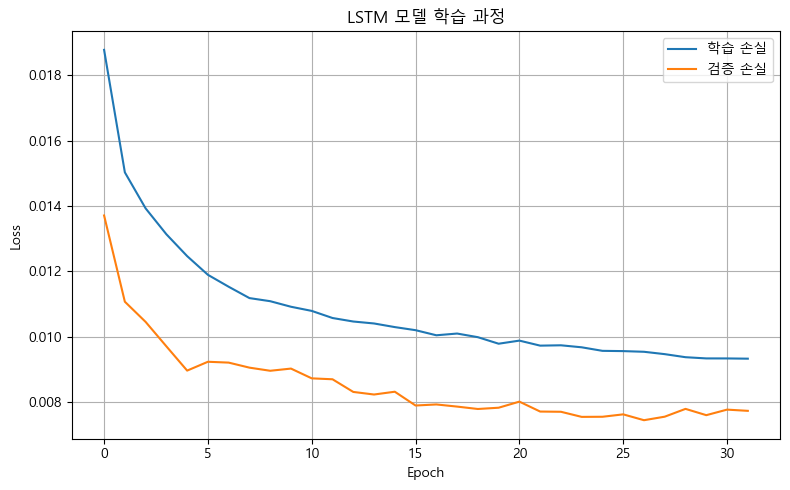

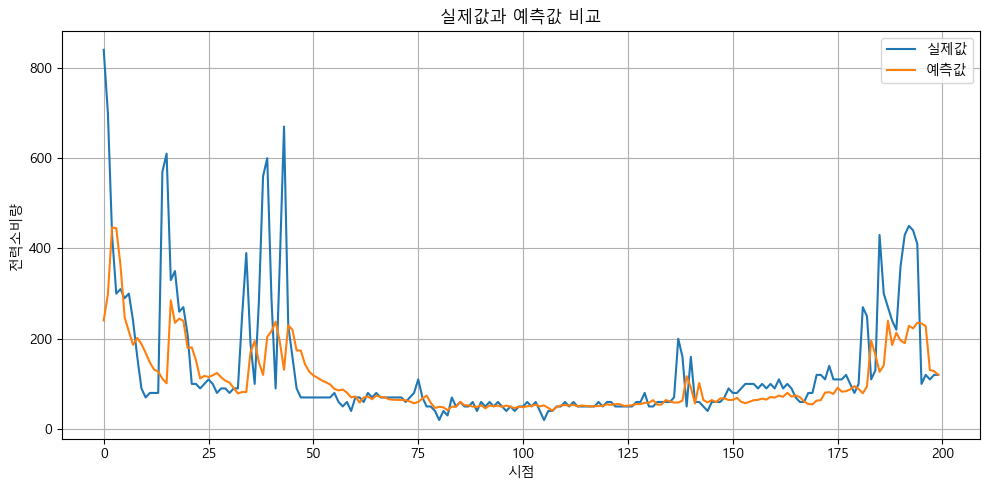

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

file_path = './dataset/KAG_energydata_complete.csv'
df = pd.read_csv(file_path)

df['date'] = pd.to_datetime(df['date'])
df['Hour'] = df['date'].dt.hour
df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

df['Appliances_lag1'] = df['Appliances'].shift(1)
df['Appliances_lag2'] = df['Appliances'].shift(2)
df['Appliances_lag3'] = df['Appliances'].shift(3)

df = df.dropna().reset_index(drop=True)

features = [
    'T_out',            # 실외온도
    'RH_out',           # 실외습도
    'T1',               # 실내온도1
    'RH_1',             # 실내습도1
    'lights',           # 조명전력
    'Tdewpoint',        # 이슬점온도
    'Press_mm_hg',      # 기압
    'Hour_sin',         # 시간 주기 변수
    'Hour_cos',
    'Appliances_lag1',  # 과거 전력값
    'Appliances_lag2',
    'Appliances_lag3'
]
target = 'Appliances'

X = df[features].values
y = df[target].values.reshape(-1, 1)

y_log = np.log1p(y)

def create_sequences(X_data, y_data, seq_length):
    X_seq = []
    y_seq = []

    for i in range(len(X_data) - seq_length):
        X_seq.append(X_data[i:i + seq_length])
        y_seq.append(y_data[i + seq_length])

    return np.array(X_seq), np.array(y_seq)

seq_length = 48

X_seq, y_seq = create_sequences(X, y_log, seq_length)

split_idx = int(len(X_seq) * 0.8)

X_train = X_seq[:split_idx]
X_test = X_seq[split_idx:]
y_train = y_seq[:split_idx]
y_test = y_seq[split_idx:]

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train_2d = X_train.reshape(-1, X_train.shape[2])
X_test_2d = X_test.reshape(-1, X_test.shape[2])

X_train_scaled = x_scaler.fit_transform(X_train_2d).reshape(X_train.shape)
X_test_scaled = x_scaler.transform(X_test_2d).reshape(X_test.shape)

y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

model = Sequential()
model.add(Input(shape=(seq_length, X_train_scaled.shape[2])))
model.add(LSTM(64, activation='tanh', return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(32, activation='tanh'))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_scaled, y_test_scaled),
    verbose=2,
    shuffle=False,
    callbacks=[early_stop]
)

y_pred_scaled = model.predict(X_test_scaled)

y_pred_log = y_scaler.inverse_transform(y_pred_scaled)
y_test_log = y_scaler.inverse_transform(y_test_scaled)

y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test_log)

mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_original, y_pred)
r2 = r2_score(y_test_original, y_pred)

print("예측 완료")
print("실제값 예시:", y_test_original[:5].flatten())
print("예측값 예시:", y_pred[:5].flatten())
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='학습 손실')
plt.plot(history.history['val_loss'], label='검증 손실')
plt.title('LSTM 모델 학습 과정')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('lstm_training_loss.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

plt.figure(figsize=(10, 5))
plt.plot(y_test_original[:200], label='실제값')
plt.plot(y_pred[:200], label='예측값')
plt.title('실제값과 예측값 비교')
plt.xlabel('시점')
plt.ylabel('전력소비량')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('lstm_prediction_compare.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

model.save("./model/model.keras")

with open("./model/X_scaler.pkl", "wb") as f:
    pickle.dump(x_scaler, f)

with open("./model/y_scaler.pkl", "wb") as f:
    pickle.dump(y_scaler, f)

with open("./model/model_config.pkl", "wb") as f:
    pickle.dump({
        "features": features,
        "seq_length": seq_length
    }, f)

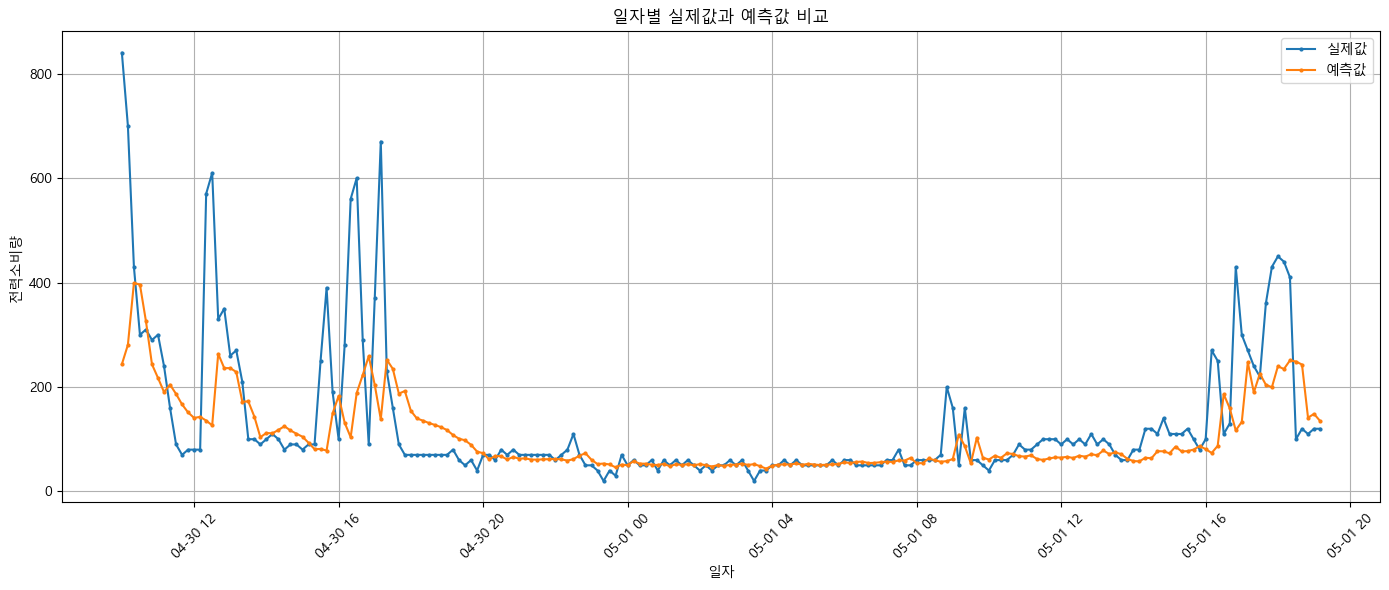

In [5]:
date_values = df['date'].iloc[seq_length:].reset_index(drop=True)
test_dates = date_values.iloc[split_idx:].reset_index(drop=True)
y_test_plot = y_test_original.flatten()
y_pred_plot = y_pred.flatten()
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(14, 6))
plt.plot(test_dates[:200], y_test_plot[:200], label='실제값', marker='o', markersize=2)
plt.plot(test_dates[:200], y_pred_plot[:200], label='예측값', marker='o', markersize=2)
plt.title('일자별 실제값과 예측값 비교')
plt.xlabel('일자')
plt.ylabel('전력소비량')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('daily_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()